In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

data = pd.read_csv("Data/binary_train_cleaned.csv")
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X

,Neighborhood_Sawyer,MasVnrType_Stone,Exterior1st_AsbShng,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,MasVnrType_BrkFace,Exterior1st_ImStucc,...,Neighborhood_ClearCr,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_MeadowV,Neighborhood_IDOTRR,Neighborhood_Gilbert,Neighborhood_Edwards,Neighborhood_Crawfor,Neighborhood_Mitchel,Neighborhood_OldTown
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1408,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1409,False,False,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1410,False,False,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


# Precent of Trues
We will ignore those that have less then `5%` of trues. (These features distinguishes less than 71 observations)

In [48]:
0.05*data.shape[0]

70.60000000000001

In [49]:
cols = X.columns

cut_off = 0.05
precent = {}
for col in cols:
    precent[col] = X[col].sum()/X.shape[0]

df_p = pd.DataFrame.from_dict(precent, orient='index')
df_p.columns = ["%"]
df_p.sort_values(by="%", ascending=True, inplace=True)


df_p[df_p['%'] > 0.05]

,%
Neighborhood_Sawyer,0.050992
Neighborhood_NWAmes,0.051700
GarageType_NA,0.052408
Neighborhood_NridgHt,0.053116
Neighborhood_Gilbert,0.054533
PavedDrive_N,0.056657
Neighborhood_Somerst,0.058782
GarageType_BuiltIn,0.060198
Electrical_FuseA,0.062323
Neighborhood_Edwards,0.063031


In [50]:
columns = list(df_p[df_p['%'] > 0.05].index)
new_data = data[columns]

new_data

,Neighborhood_Sawyer,Neighborhood_NWAmes,GarageType_NA,Neighborhood_NridgHt,Neighborhood_Gilbert,PavedDrive_N,Neighborhood_Somerst,GarageType_BuiltIn,Electrical_FuseA,Neighborhood_Edwards,...,RoofStyle_Gable,MSZoning_RL,SaleType_WD,MasVnrType_BrkFace,Electrical_SBrkr,PavedDrive_Y,CentralAir,HasGarage,Heating_GasA,Street_Pave
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,False,False,False,False,True,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1408,False,True,False,False,False,False,False,False,False,False,...,True,True,True,False,True,True,True,True,True,True
1409,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1410,False,False,False,False,False,False,False,False,True,False,...,False,True,True,True,False,True,True,True,True,True


# Group Test
from [EDA_intro](3_EDA_intro.ipynb) we know that we can't assume that target has normal distribution. That is why we will use Whitney U-test.

In [79]:
def analyze_binary_split(df, target, binary_col, plot = True):

    group0 = target[df[binary_col].values]
    group1 = target[~df[binary_col].values]

    u_stat, p_value = stats.mannwhitneyu(group0, group1, alternative='two-sided')

    if plot:
        #Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Histogram / KDE Plot
        sns.histplot(group0, color="skyblue", label=f"{binary_col}=0", ax=ax1, stat="density", common_norm=False)
        sns.histplot(group1, color="orange", label=f"{binary_col}=1",  ax=ax1, stat="density", common_norm=False)
        ax1.set_title(f"Distribution of SalePrice\nby {binary_col}")
        ax1.legend()

        # Probability Plot (QQ-Plot)
        sns.scatterplot(group1, color="orange", label=f"{binary_col}=1",  ax=ax2,  alpha=0.5)
        sns.scatterplot(group0, color="skyblue", label=f"{binary_col}=0", ax=ax2)
        ax2.set_title(f"Scatter Plot for SalePrice")

        plt.tight_layout()
        plt.show()

    print(f"--- Analysis for {binary_col} ---")
    print(f"Group 0 Mean: {group0.mean():.2f} (n={len(group0)})")
    print(f"Group 1 Mean: {group1.mean():.2f} (n={len(group1)})")
    print(f"U-Statistic: {u_stat:.2f}, P-value: {p_value:.4e}")

    if p_value < 0.05:
        print("Result: Statistically Significant difference found between groups.")
    else:
        print("Result: No significant difference; groups are similar.")

    return u_stat, p_value


analyze_binary_split(X,y, 'GarageType_NA', plot=False)

--- Analysis for GarageType_NA ---
Group 0 Mean: 105576.35 (n=74)
Group 1 Mean: 186761.78 (n=1338)
U-Statistic: 12245.00, P-value: 1.0034e-27
Result: Statistically Significant difference found between groups.


(12245.0, 1.0034049198499725e-27)

In [80]:
columns = new_data.columns
valid_features_col = []
invalid_features_col = []

for c in columns:
    u, p = analyze_binary_split(X, y, c, False)

    if p < 0.05:
        valid_features_col.append(c)
    else:
        invalid_features_col.append(c)

print(f' There is {len(valid_features_col)} columns that distinguish groups')

--- Analysis for Neighborhood_Sawyer ---
Group 0 Mean: 137787.39 (n=72)
Group 1 Mean: 184909.87 (n=1340)
U-Statistic: 28875.00, P-value: 9.1769e-09
Result: Statistically Significant difference found between groups.
--- Analysis for Neighborhood_NWAmes ---
Group 0 Mean: 189050.07 (n=73)
Group 1 Mean: 182150.31 (n=1339)
U-Statistic: 60381.50, P-value: 6.9390e-04
Result: Statistically Significant difference found between groups.
--- Analysis for GarageType_NA ---
Group 0 Mean: 105576.35 (n=74)
Group 1 Mean: 186761.78 (n=1338)
U-Statistic: 12245.00, P-value: 1.0034e-27
Result: Statistically Significant difference found between groups.
--- Analysis for Neighborhood_NridgHt ---
Group 0 Mean: 314717.84 (n=75)
Group 1 Mean: 175090.56 (n=1337)
U-Statistic: 90300.00, P-value: 1.4669e-31
Result: Statistically Significant difference found between groups.
--- Analysis for Neighborhood_Gilbert ---
Group 0 Mean: 192857.22 (n=77)
Group 1 Mean: 181910.04 (n=1335)
U-Statistic: 65923.50, P-value: 2.9783e

# Analyze invalid ones

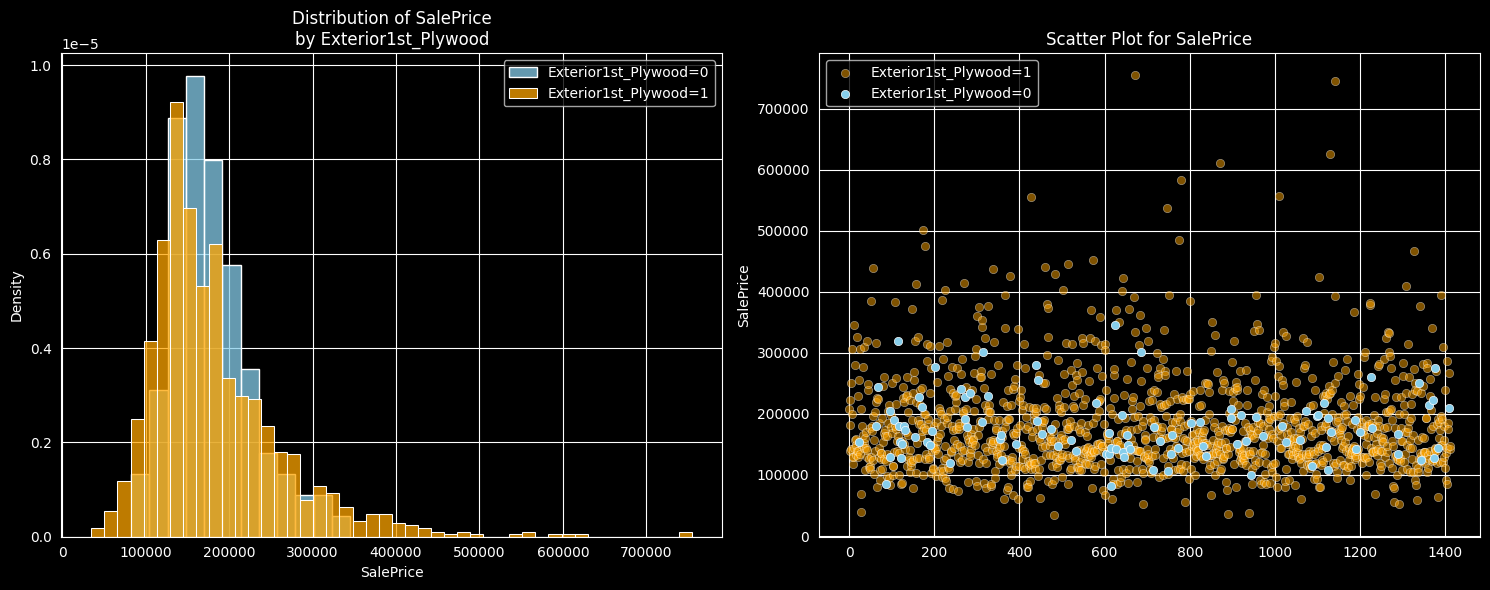

--- Analysis for Exterior1st_Plywood ---
Group 0 Mean: 177679.28 (n=103)
Group 1 Mean: 182886.90 (n=1309)
U-Statistic: 71162.50, P-value: 3.4681e-01
Result: No significant difference; groups are similar.


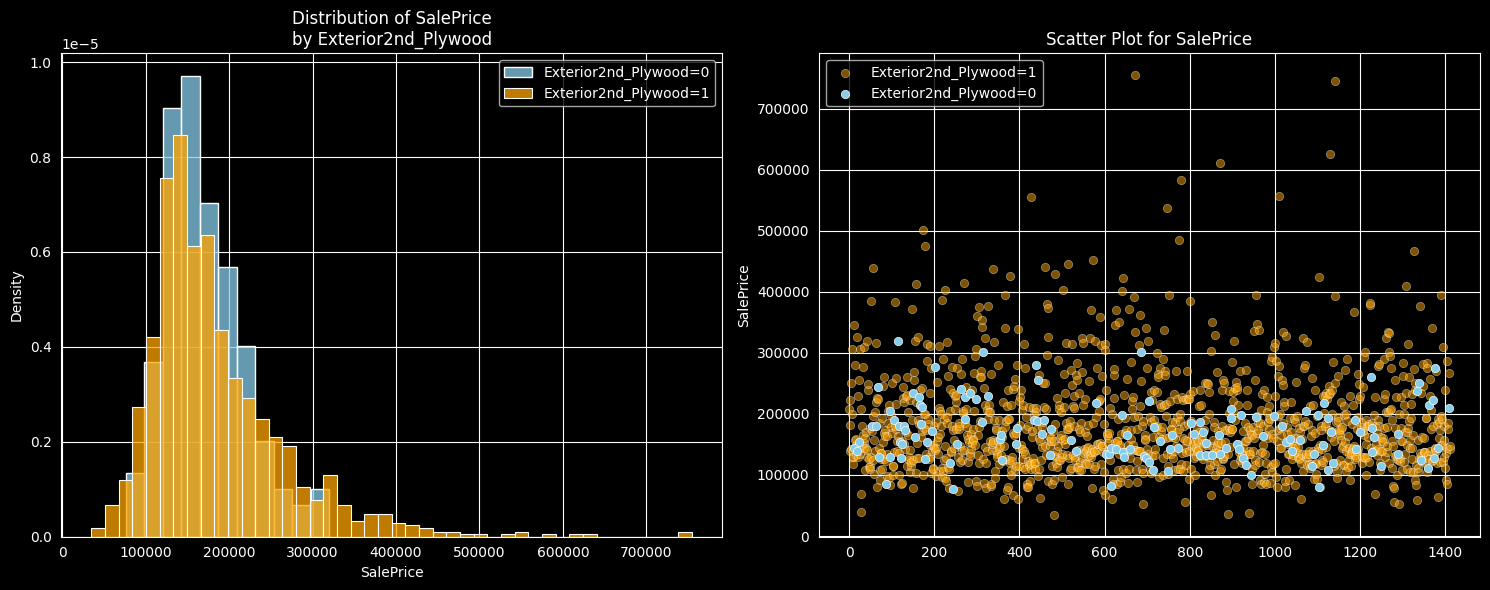

--- Analysis for Exterior2nd_Plywood ---
Group 0 Mean: 170034.93 (n=135)
Group 1 Mean: 183825.53 (n=1277)
U-Statistic: 83803.00, P-value: 5.9517e-01
Result: No significant difference; groups are similar.


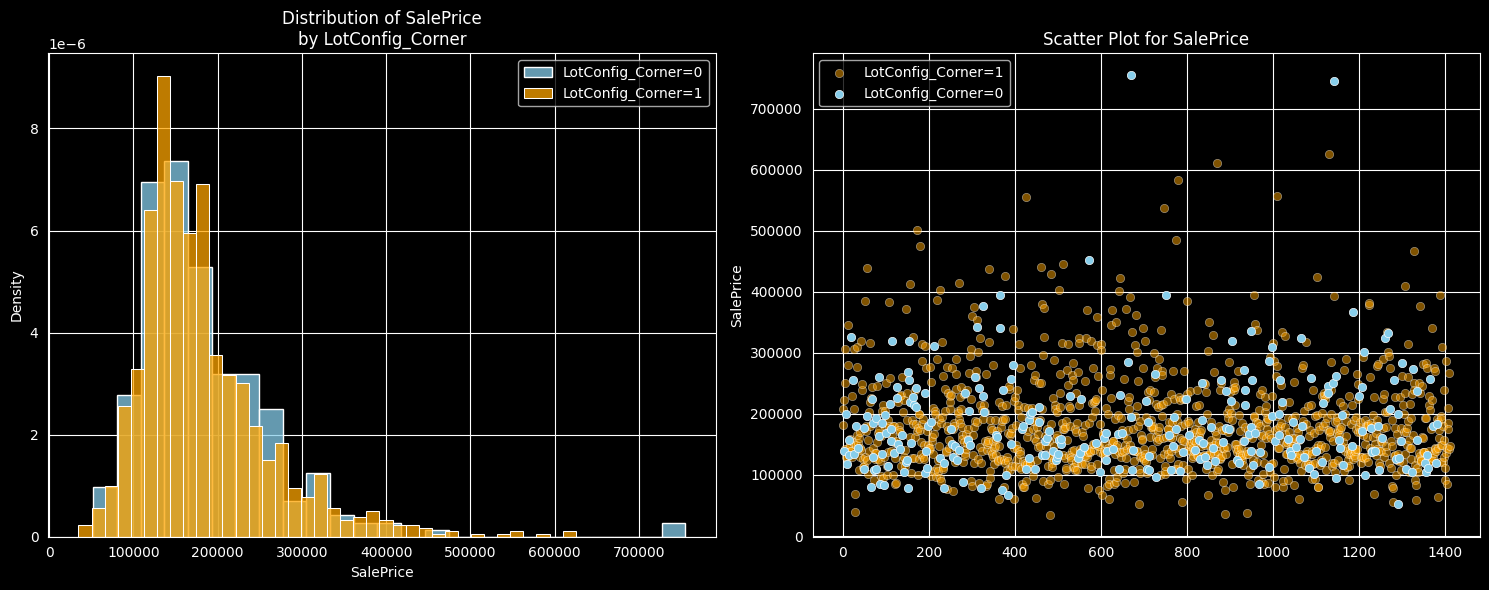

--- Analysis for LotConfig_Corner ---
Group 0 Mean: 183113.52 (n=256)
Group 1 Mean: 182372.71 (n=1156)
U-Statistic: 147056.50, P-value: 8.7735e-01
Result: No significant difference; groups are similar.


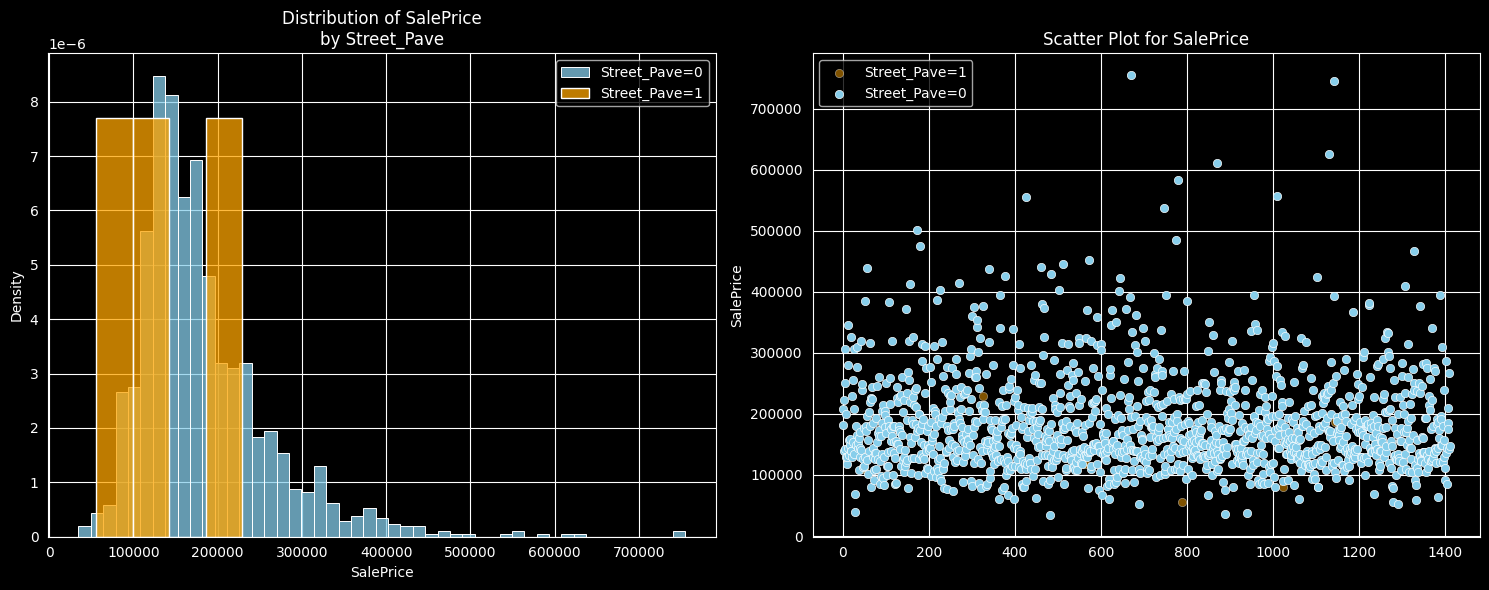

--- Analysis for Street_Pave ---
Group 0 Mean: 182730.28 (n=1406)
Group 1 Mean: 130190.50 (n=6)
U-Statistic: 6019.50, P-value: 7.0755e-02
Result: No significant difference; groups are similar.


In [81]:
for c in invalid_features_col:
    analyze_binary_split(X, y, c, True)

# Check of random valid ones

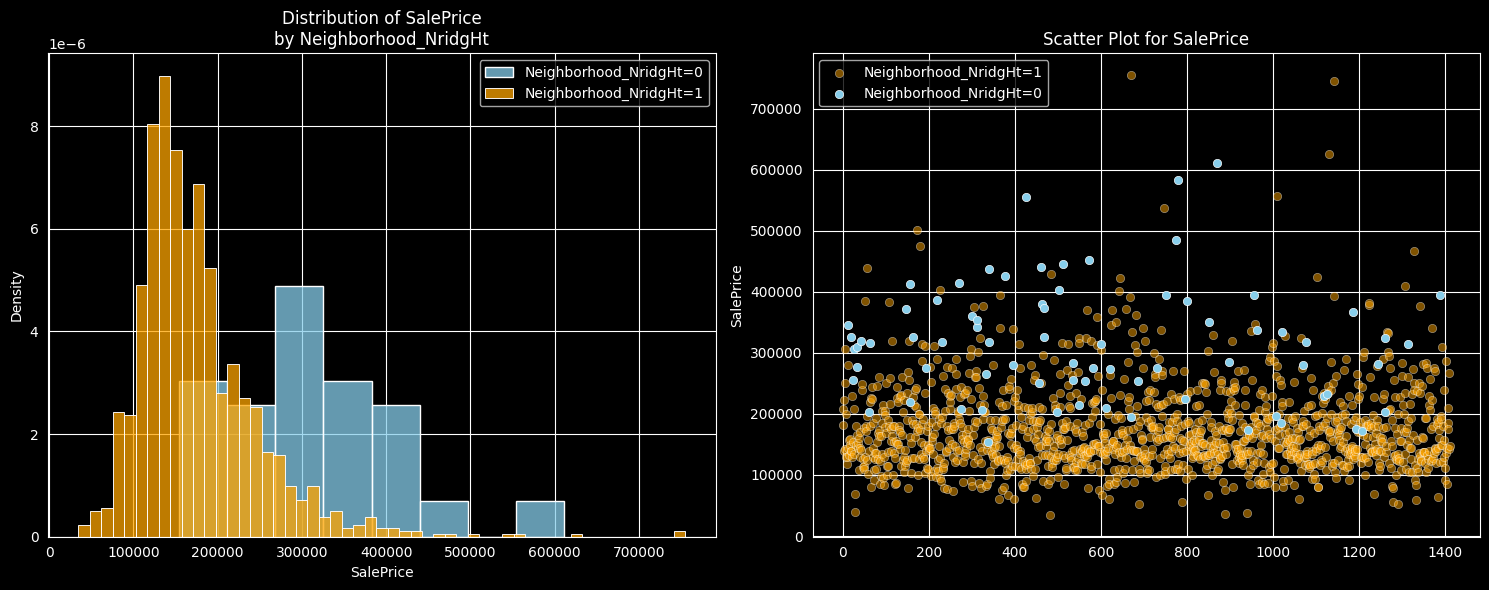

--- Analysis for Neighborhood_NridgHt ---
Group 0 Mean: 314717.84 (n=75)
Group 1 Mean: 175090.56 (n=1337)
U-Statistic: 90300.00, P-value: 1.4669e-31
Result: Statistically Significant difference found between groups.


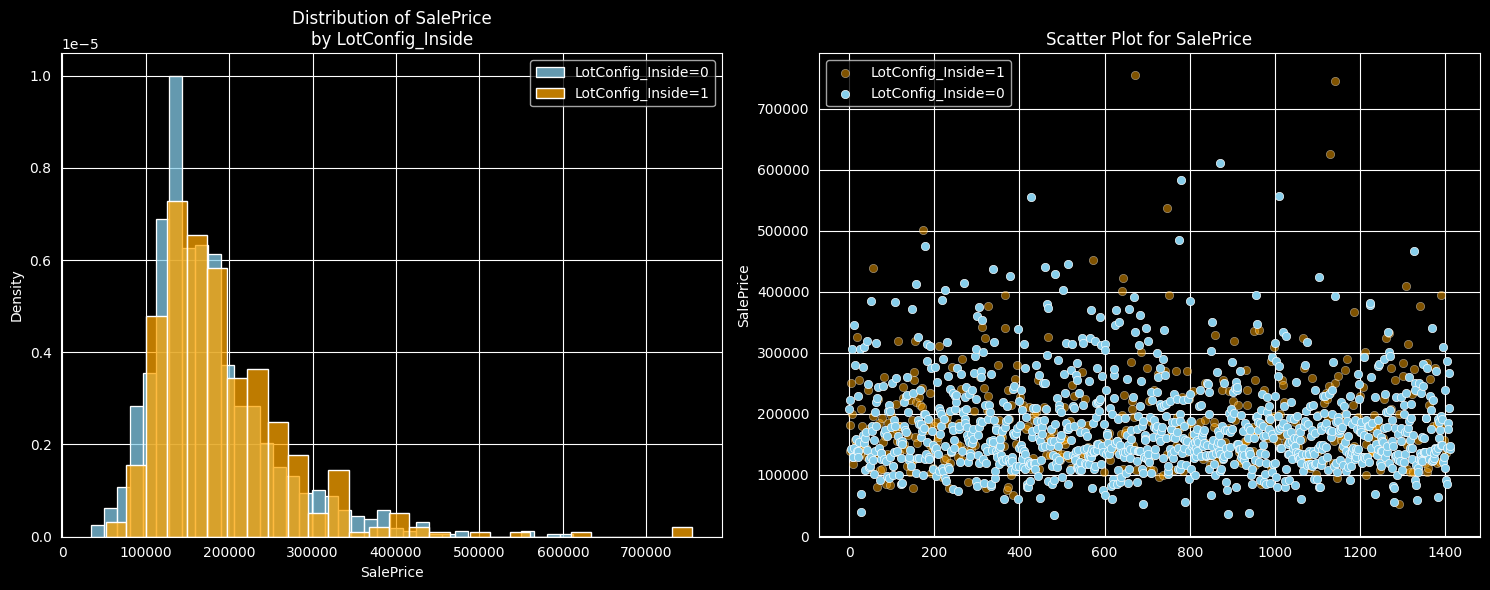

--- Analysis for LotConfig_Inside ---
Group 0 Mean: 178433.22 (n=1015)
Group 1 Mean: 192922.41 (n=397)
U-Statistic: 178519.50, P-value: 8.5951e-04
Result: Statistically Significant difference found between groups.


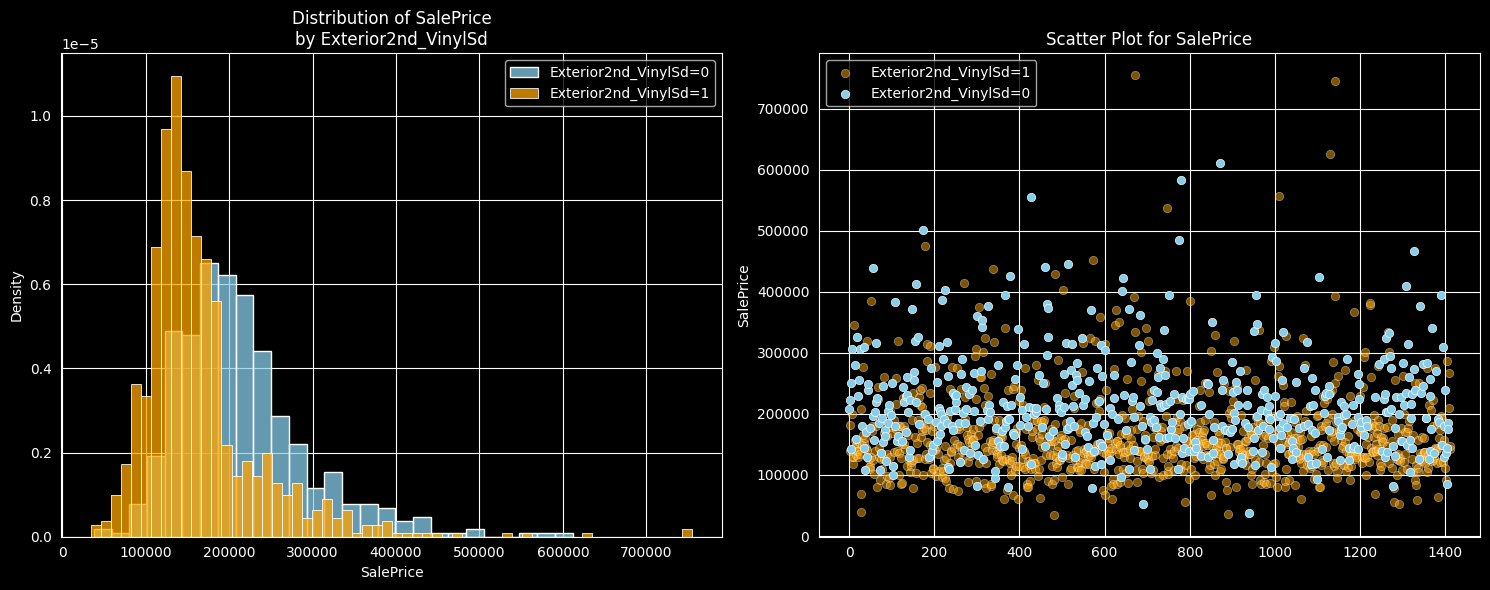

--- Analysis for Exterior2nd_VinylSd ---
Group 0 Mean: 215249.21 (n=491)
Group 1 Mean: 165051.63 (n=921)
U-Statistic: 327837.50, P-value: 3.5457e-44
Result: Statistically Significant difference found between groups.


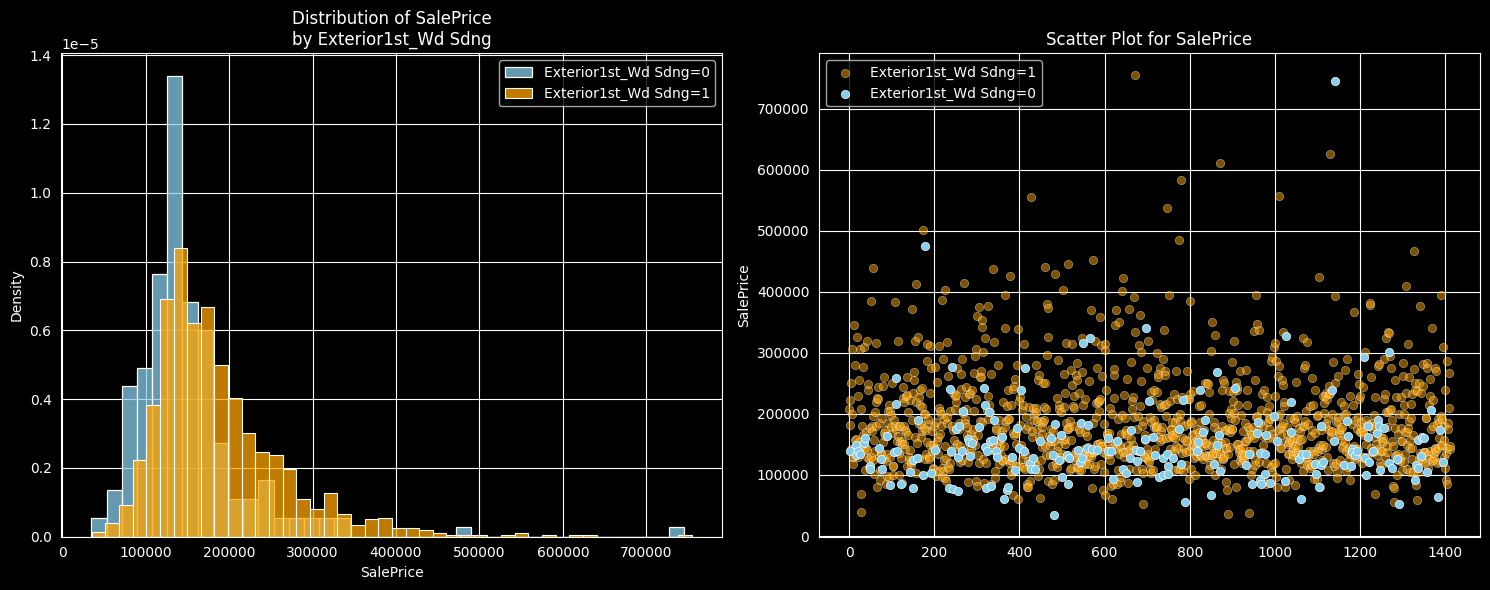

--- Analysis for Exterior1st_Wd Sdng ---
Group 0 Mean: 150548.53 (n=201)
Group 1 Mean: 187811.45 (n=1211)
U-Statistic: 80242.50, P-value: 9.5749e-15
Result: Statistically Significant difference found between groups.


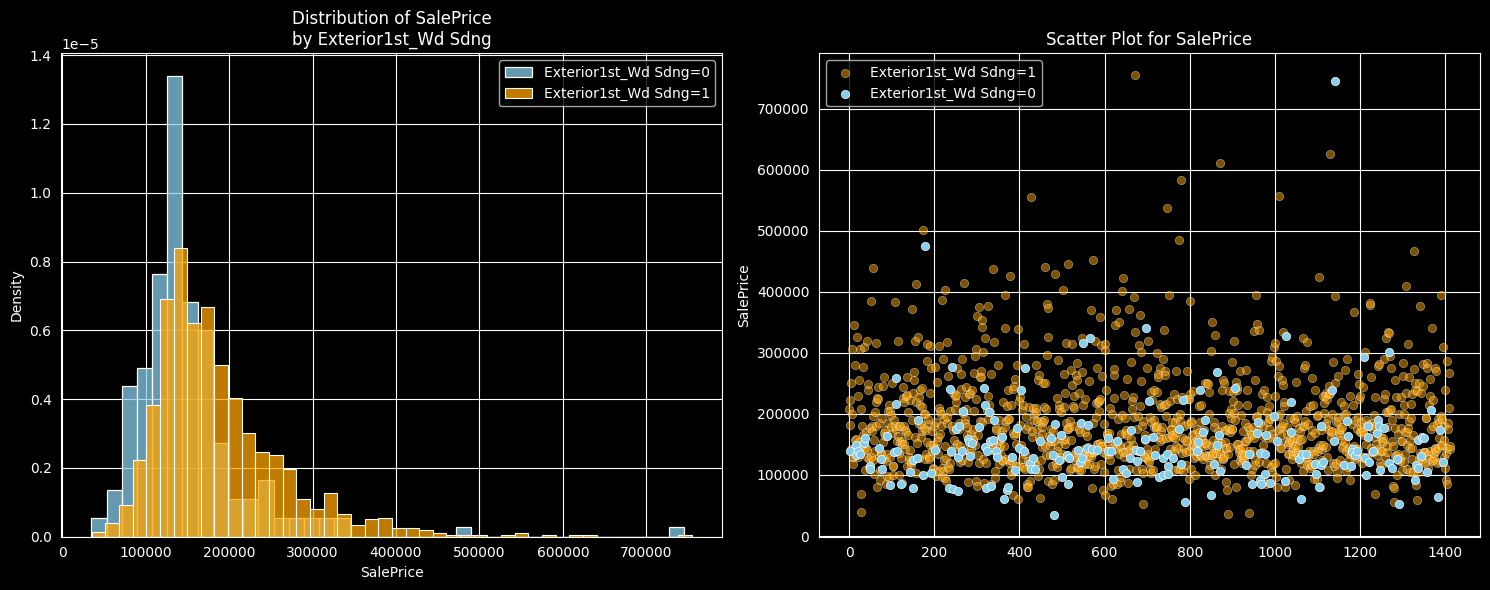

--- Analysis for Exterior1st_Wd Sdng ---
Group 0 Mean: 150548.53 (n=201)
Group 1 Mean: 187811.45 (n=1211)
U-Statistic: 80242.50, P-value: 9.5749e-15
Result: Statistically Significant difference found between groups.


In [85]:
rng = np.random.default_rng(42)
idx = rng.integers(low=0, high=len(valid_features_col), size=5)

for i in idx:
    analyze_binary_split(X, y, valid_features_col[i], True)
